In [ ]:
!python -m pip install scikit-learn
!env\Scripts\Activate.ps1 



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# imports 
import pandas as pd 
import scikit-learn


SyntaxError: invalid syntax (3022832359.py, line 3)

NameError: name 'tf' is not defined

# Dataset loading and preprocessing


# Kalman (SELF-CARE) ensemble



## 1. Data Collection & Setup
Devices: wrist‑ or finger‑mounted GSR, PPG, and skin‑temperature sensors.

Protocol: record during your baseline vs. stress (and any other) tasks, ensuring you log a synchronized timestamp and a ground‑truth label stream.

Storage: keep each subject’s raw streams (timestamp + value) in a uniform format (e.g. one CSV or pickle per subject).

## 2. Preprocessing
Resample & Align

Choose a reference rate (e.g. your highest‑rate sensor) and up/down‑sample the others so all three share a common timestamp index.

Filtering

GSR: low‑pass Butterworth (∼1 Hz) to remove high‑frequency noise; optionally run cvxEDA to split phasic/tonic components.

PPG: band‑pass (0.5–8 Hz) to isolate the pulse waveform; remove baseline wander.

TEMP: low‑pass (∼0.5 Hz) to smooth out rapid fluctuations.

Windowing

Segment into fixed windows (e.g. 1 s non‑overlapping or 50 % overlap).

Assign each window a label (e.g. via majority vote or forward‑fill from your label stream).

## 3. Context Identification (Gating)
Since you don’t have ACC, use a signal‑quality or motion proxy derived from your sensors—for example:

PPG SQI: compute the ratio of high‑ to low‑frequency power, or the standard deviation of beat‑to‑beat intervals.

GSR Variability: the variance or spectral entropy of the tonic component.

Extract SQI Features per window.

Train a Decision Tree on these SQIs to predict which “branch” (sensor subset) to run.

Performance‑Energy Trade‑off (δ)

Let b̄ = branch with highest gating probability.

Activate any branch with prob ≥ b̄ − δ (δ∈[0,1] controls how many extra branches you’ll allow).

## 4. Branch Classifier Training
Define Your Branches (early‑fusion subsets), e.g.:

B1 = {GSR, PPG, TEMP}

B2 = {GSR, PPG}

B3 = {GSR, TEMP}

B4 = {PPG, TEMP}

Feature Extraction

For each window & each branch, compute summary stats (mean, std, min, max) on each modality + any domain‑specific features (e.g. PPG peak frequency, GSR phasic amplitude, TEMP slope).

Classifier Selection

For each branch, train a small suite of models (e.g. DT, RF, AB, LDA, KNN) via leave‑one‑subject‑out CV.

Pick the best‑performing classifier per branch (lowest validation loss).

5. Late Fusion with Kalman Filter
Initialize

State x₀ = your prior class‑prob vector (e.g. [0.8,0.1,0.1] for 3‑class), P₀ = small covariance.

Per‑Window Inference

Gating → select branch(es) → run their classifiers → get each’s zₜ (prob‑vector).

Threshold & Scale zₜ (ε filter + γ scaling to handle low confidence or class imbalance).

Kalman Predict/Update (A=H=I, tune process & measurement noise) to fuse zₜ into xₜ.

Output

Final stress prediction = arg max(xₜ).

6. Validation & Deployment
LOSO‑CV: test generalization across subjects.

Energy Profiling: measure per‑branch compute to pick δ.

Pipeline Packaging: wrap preprocessing → gating → branch inference → fusion into one reusable module or microservice.

Real‑Time: ensure each 1 s window (or your chosen window length) is fully processed before the next arrives.

With these tweaks—filtering GSR/PPG/TEMP, gating on signal‑quality proxies, and redefining your branches—you’ll have a SELF‑CARE–style stress detector built around your three sensors.

Source - https://ieeexplore.ieee.org/document/9881725

# CNN model with deep neural for classification


 
🔧 Model Construction (CNN-Based Time-Series Classifier)
1. Why CNN for Stress Detection?
They’re using 1D CNNs to learn directly from raw sensor data (no manual feature extraction).

CNNs are well-suited for time-series tasks (like EDA, PPG, TEMP) because they:

Capture local temporal dependencies

Are scale invariant (pattern can shift in time)

2. Architecture Summary
🔷 Input
Raw time-series window from sensors (like EDA/GSR).

🔷 Convolutional Stack
Conv Layer 1:

100 filters, kernel size 5

Learns short-term temporal patterns (e.g., sudden changes in GSR)

Conv Layer 2:

100 filters, kernel size 10

Learns longer-range or more complex patterns

Global Max Pooling:

Reduces each feature map to a single value

Removes dependency on exact input length

Feature Output:

A flat vector of aggregated features across all kernels

🔷 Dense Stack
FC1: 128 neurons, ReLU, Dropout 0.3

FC2: 64 neurons, ReLU, Dropout 0.2

Output Layer: Softmax over stress classes (e.g., stress vs. no stress or multiple levels)

🧠 Activations
ReLU: All layers except output

Softmax: Final layer for multi-class stress classification

🧬 Why No Feature Engineering?
The CNN automatically learns hierarchical features from raw input:

Low-level edges, slopes → High-level temporal events

No need for handcrafted features like peaks, slopes, derivatives—just clean, structured raw data.

👤 Model Personalization (Online Learning Loop)
1. Problem:
Stress response is subjective → same signal ≠ same label across users.

A general model may underfit or misclassify personal stress triggers.

2. Solution: Online Fine-Tuning
M1 (General Model): Pretrained on population-level dataset

While in use:

Collect labeled user data (e.g., from self-report or proxy)

Fine-tune M1 on this personal data to get M2 (Personalized Model)

Iterate until M2 achieves satisfactory performance for the individual

3. Benefits
Adapts to each user’s baseline and unique stress patterns

Reduces generalization gap between training population and end-user

🚀 Deployment Insight (for you as an ML engineer)
If you were implementing this:

You’d stream EDA/PPG/TEMP data in real-time.

Chunk into fixed-length windows → feed to the CNN

The CNN model runs on-device (for latency/privacy) or server (if bandwidth permits)

You’d implement a lightweight fine-tuning pipeline, likely using only the dense layers (frozen CNN base) for quick personalization

Consider model checkpointing and gradual learning rate decay to avoid overfitting during personalization

Source - https://ieeexplore.ieee.org/document/9871842

In [ ]:
import numpy as np


data = np.load('C:/codes/Projects/Naari-Sahyog/raw_sequences.npz')
X, y = data['X'], data['y']
print("X shape:", X.shape)  # (num_windows, 64, 3)
print("y shape:", y.shape)  # (num_windows,)

# Keep only baseline (1) and stress (2)
mask = (y == 1) | (y == 2)
X = X[mask]
y = y[mask]

# Relabel: baseline = 0, stress = 1
y = (y == 2).astype(int)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

X_mean = X_train.mean(axis=(0, 1), keepdims=True)
X_std = X_train.std(axis=(0, 1), keepdims=True)

X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

# Save the normalization values
import pickle

normalization_values = {
    'mean': X_mean,
    'std': X_std
}

# Save to a file
with open('normalization_values.pkl', 'wb') as f:
    pickle.dump(normalization_values, f)

print("Normalization values saved to normalization_values.pkl")

X shape: (90479, 64, 3)
y shape: (90479,)
Train: (22980, 64, 3) (22980,)
Test : (5746, 64, 3) (5746,)
Normalization values saved to normalization_values.pkl


# data plotings

X shape: (90479, 64, 3)
y shape: (90479,)
Number of samples: 90479
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


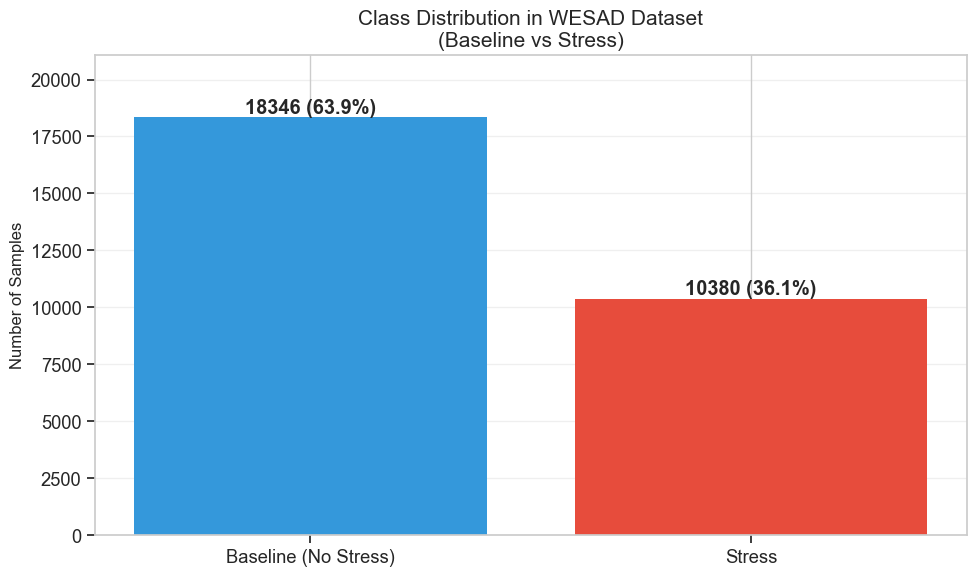

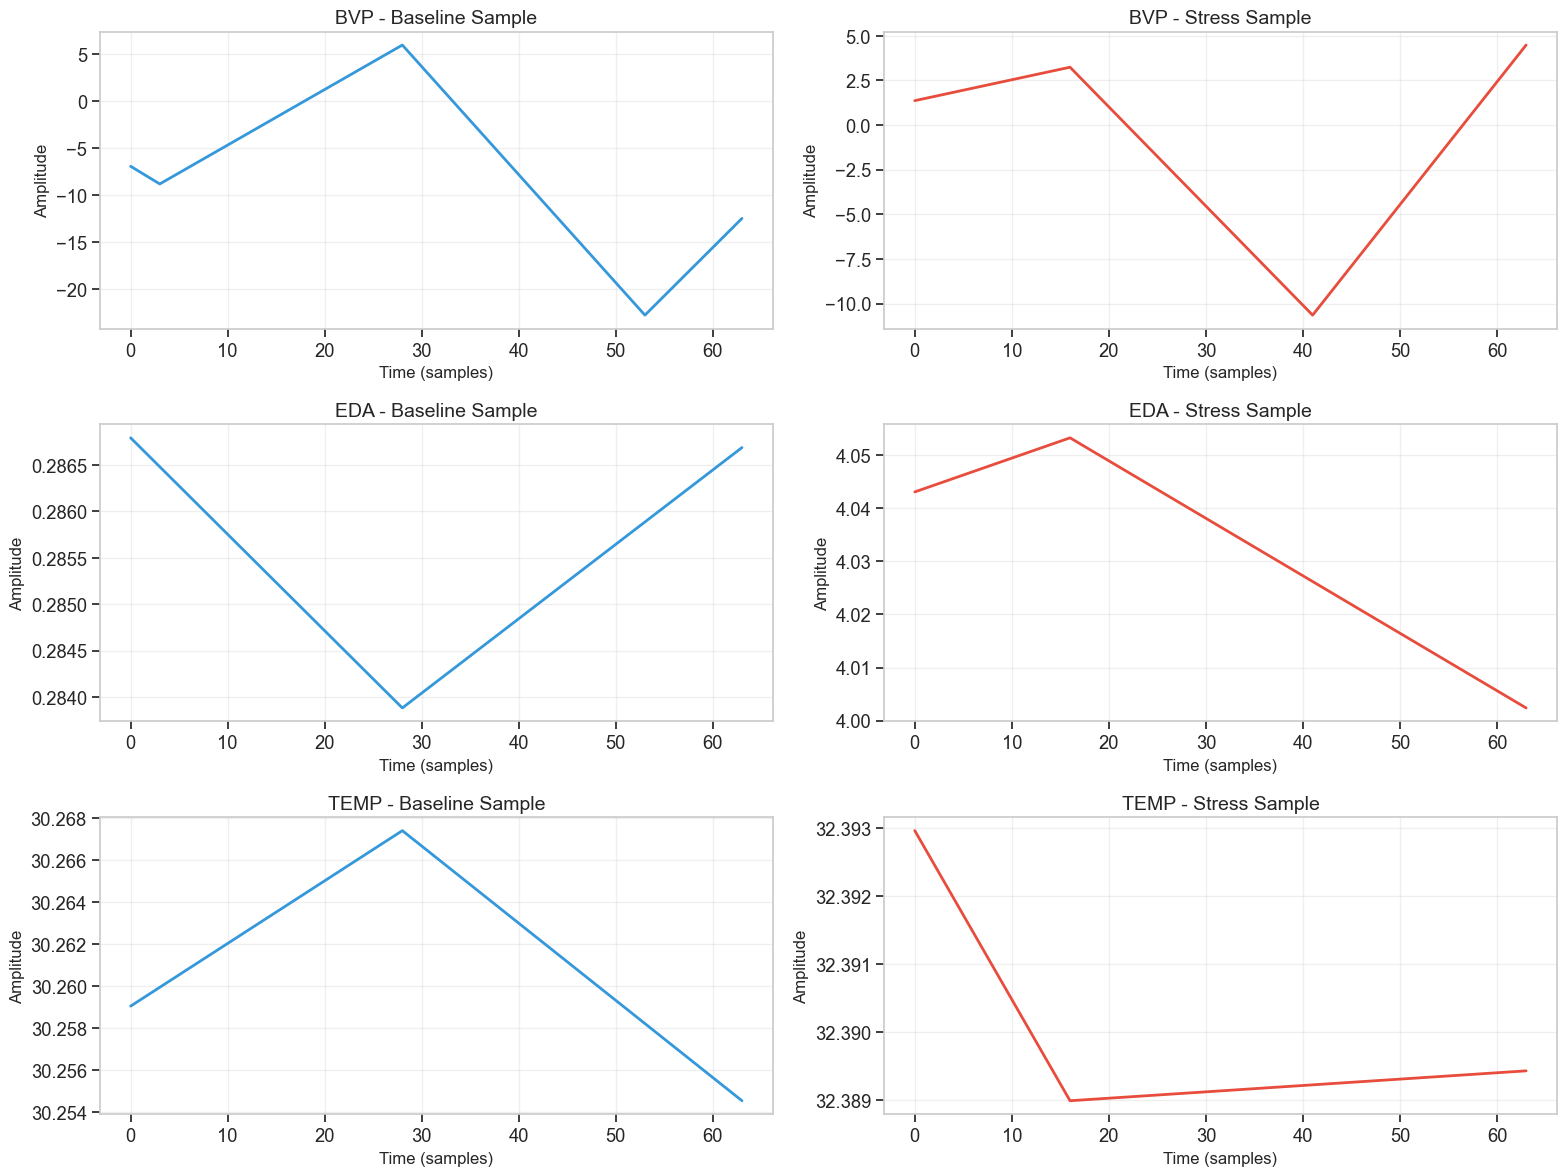

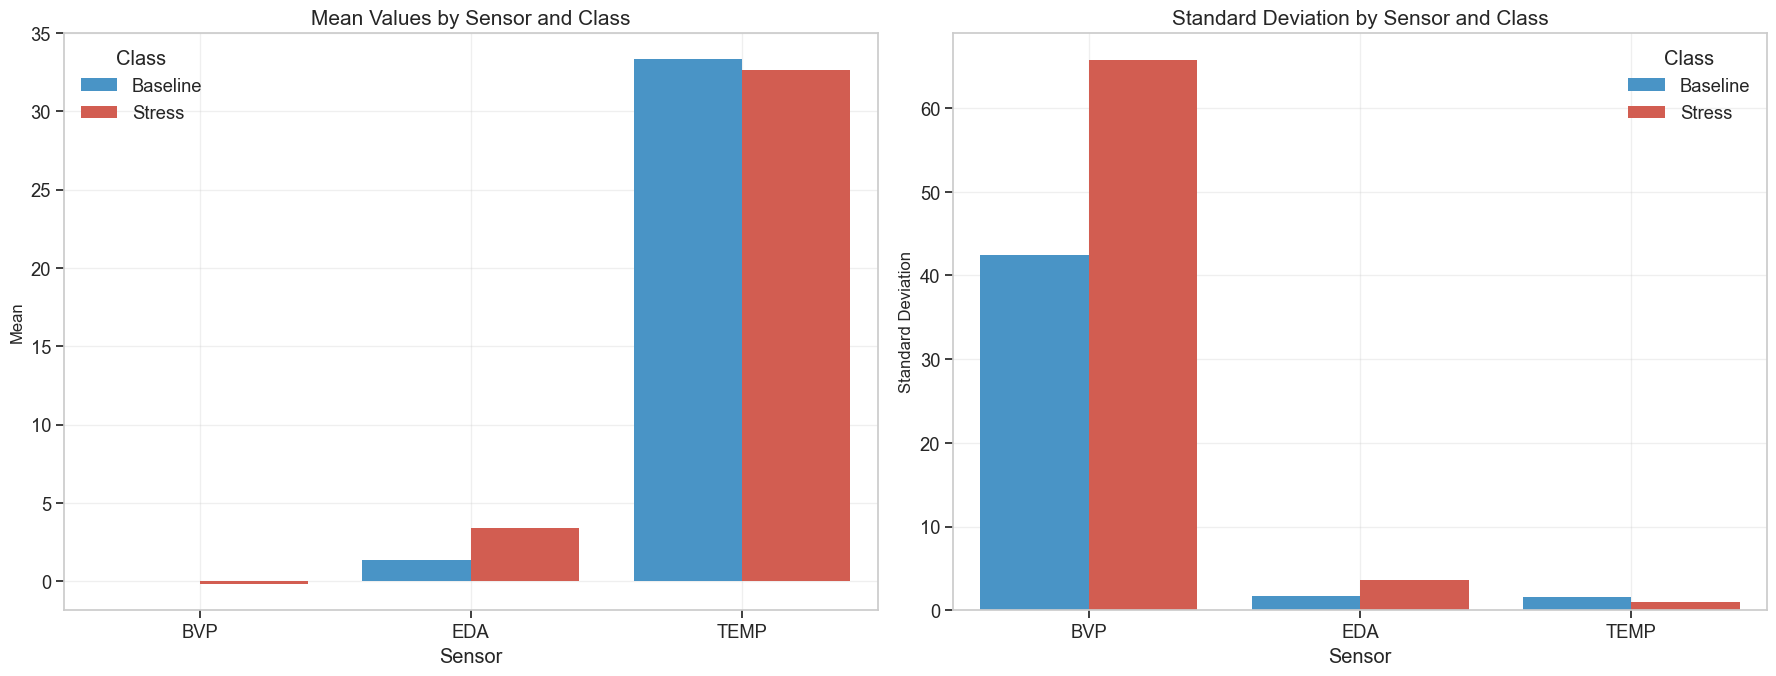

Statistical Significance (t-test p-values):
-------------------------------------------
BVP: p-value = 0.0370386081 (Significant)
EDA: p-value = 0.0000000000 (Significant)
TEMP: p-value = 0.0000000000 (Significant)
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


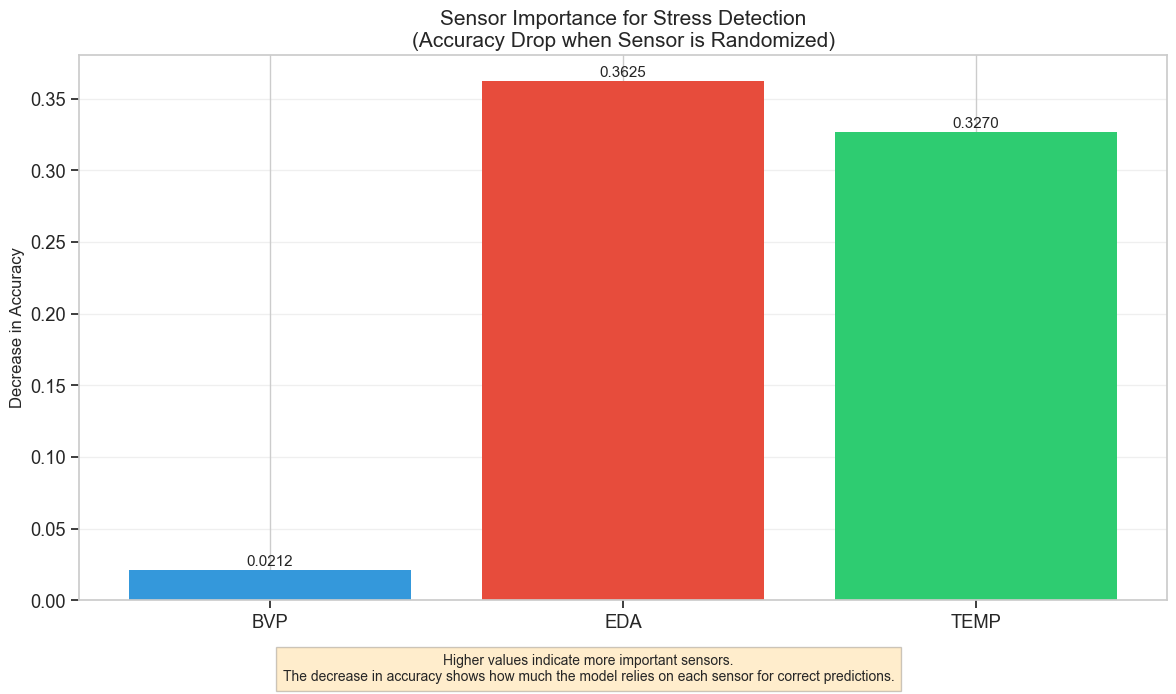

Sensor Importance Analysis
-------------------------
BVP: 0.0212 decrease in accuracy when randomized
EDA: 0.3625 decrease in accuracy when randomized
TEMP: 0.3270 decrease in accuracy when randomized

The most important sensor for stress detection is: EDA


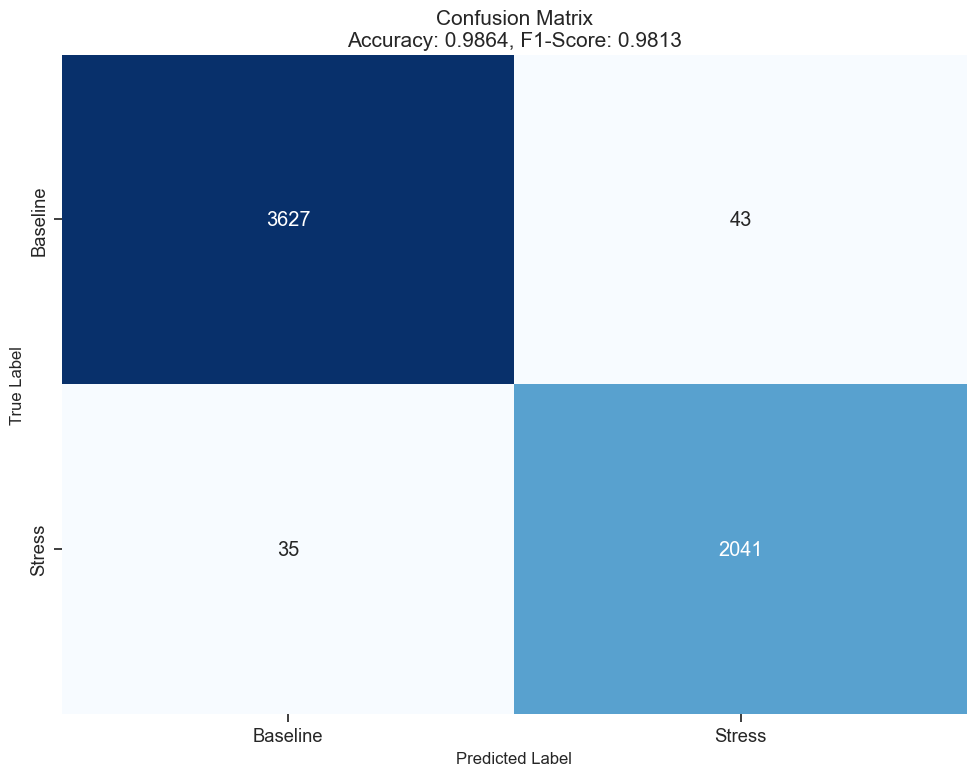

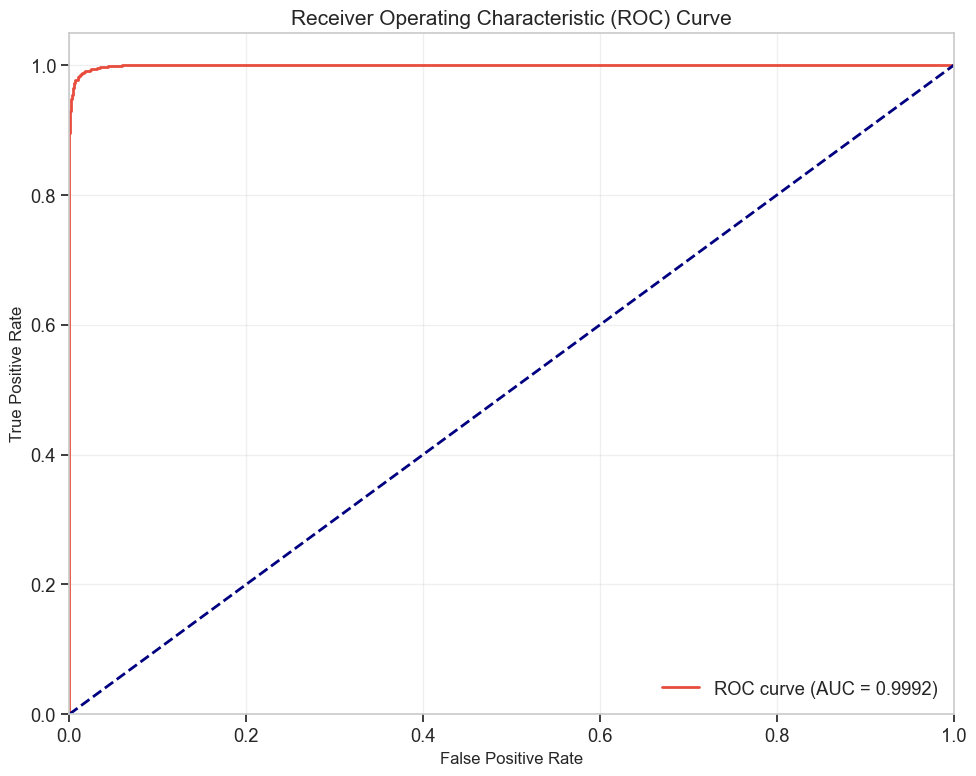

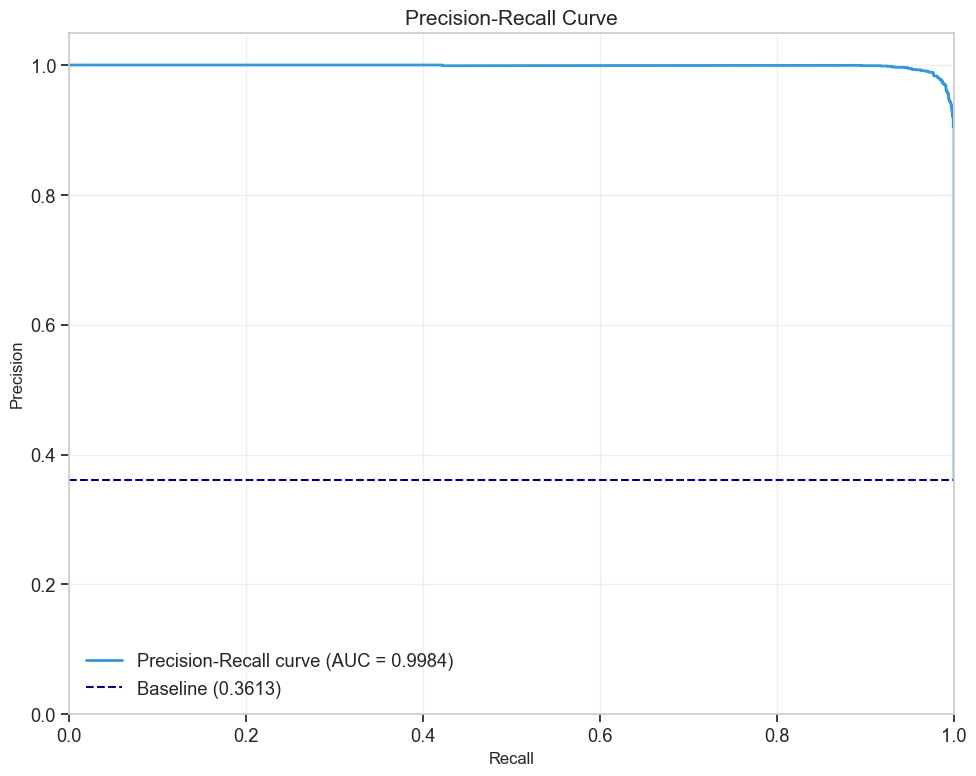

Classification Report:
---------------------
              precision    recall  f1-score   support

    Baseline       0.99      0.99      0.99      3670
      Stress       0.98      0.98      0.98      2076

    accuracy                           0.99      5746
   macro avg       0.98      0.99      0.99      5746
weighted avg       0.99      0.99      0.99      5746



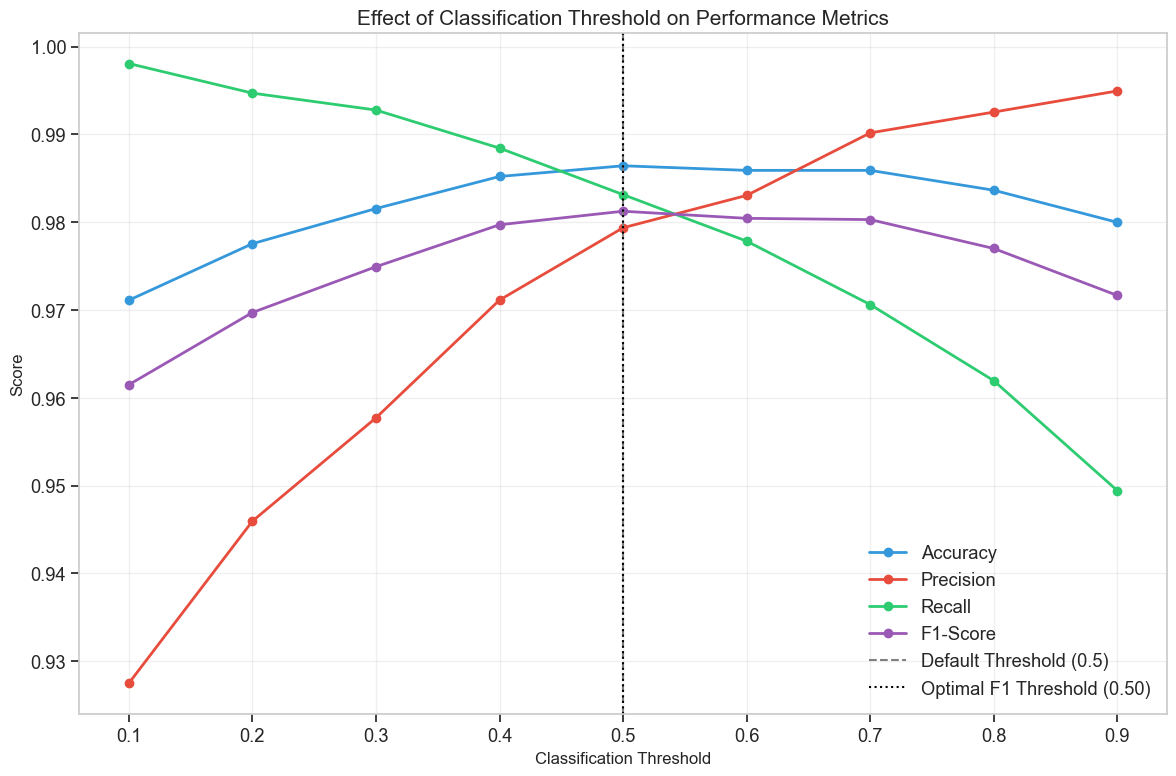

Optimal Threshold Analysis:
---------------------------
Optimal threshold for F1-Score: 0.50
Metrics at optimal threshold:
- Accuracy: 0.9864
- Precision: 0.9794
- Recall: 0.9831
- F1-Score: 0.9813


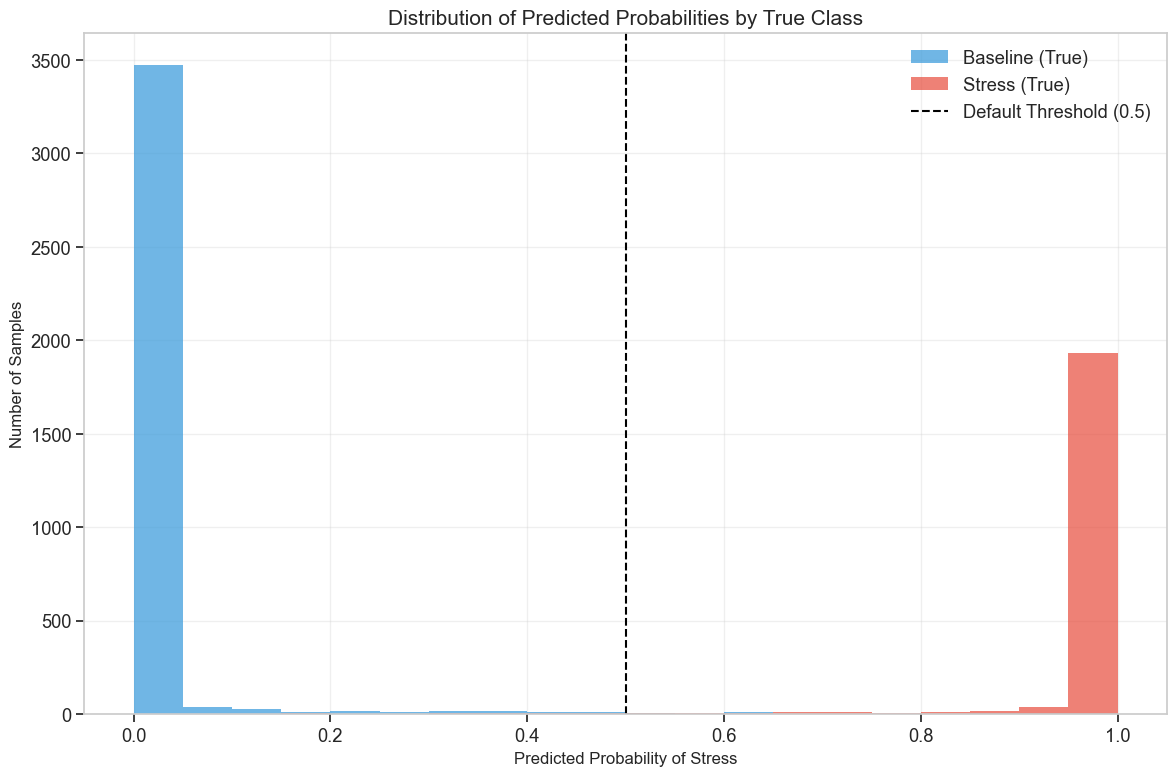

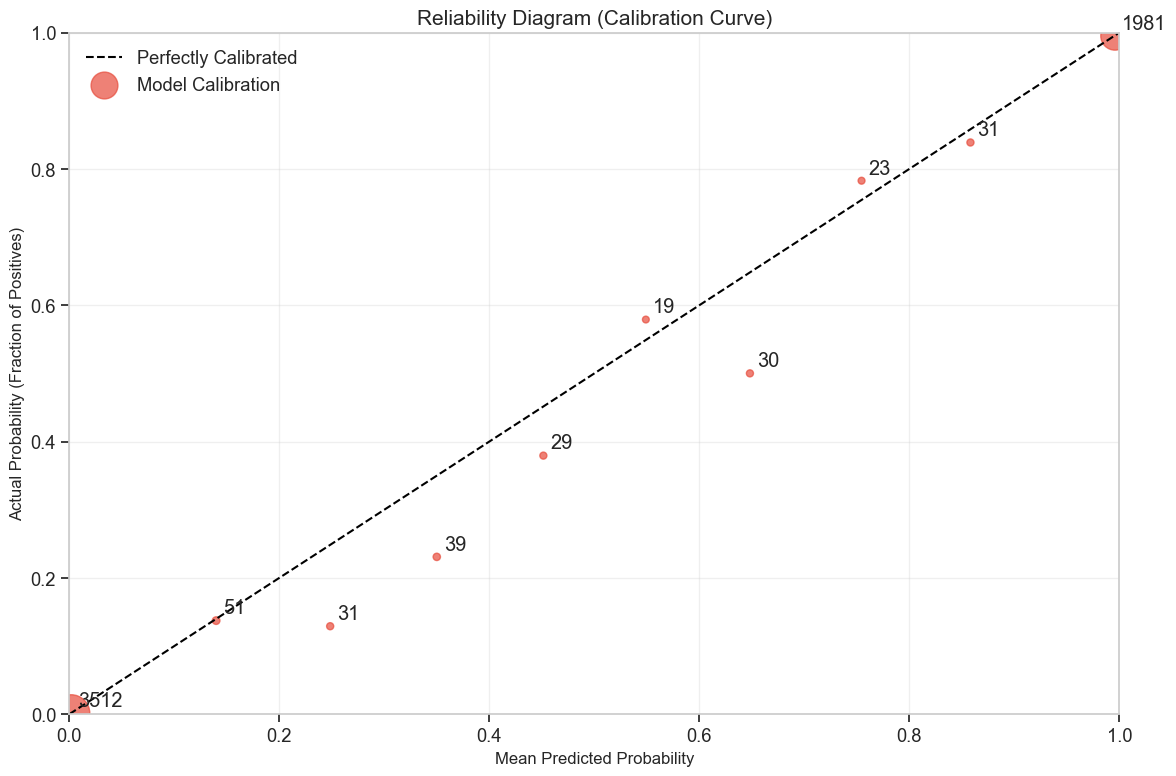

Expected Calibration Error (ECE): 0.0036
The model is relatively well-calibrated.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
import joblib
from tensorflow.keras.models import load_model
import pickle
import os
from scipy import stats

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Load the WESAD raw sequences dataset
data = np.load('C:/codes/Projects/Naari-Sahyog/raw_sequences.npz')
X, y = data['X'], data['y']
print("X shape:", X.shape)  # (num_windows, 64, 3)
print("y shape:", y.shape)  # (num_windows,)
print(f"Number of samples: {X.shape[0]}")

# Keep only baseline (1) and stress (2) as in the original code
mask = (y == 1) | (y == 2)
X = X[mask]
y = y[mask]

# Relabel: baseline = 0, stress = 1
y = (y == 2).astype(int)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Load normalization values
with open('normalization_values.pkl', 'rb') as f:
    norm_values = pickle.load(f)
    X_mean = norm_values['mean']
    X_std = norm_values['std']

# Normalize the test data
X_test_normalized = (X_test - X_mean) / X_std

# For sklearn model:
model = joblib.load('C:/codes/Projects/Naari-Sahyog/model/CNN_Model_Stress_v1.h5')

# Make predictions
y_pred_prob = model.predict(X_test_normalized)
y_pred = (y_pred_prob > 0.5).astype(int)

# For multi-class model, use argmax
if len(y_pred_prob.shape) > 1 and y_pred_prob.shape[1] > 1:
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_pred_prob = y_pred_prob[:, 1] if y_pred_prob.shape[1] > 1 else y_pred_prob

def plot_class_distribution():
    plt.figure(figsize=(10, 6))
    class_names = ['Baseline (No Stress)', 'Stress']
    
    class_counts = np.bincount(y)
    total = len(y)
    percentages = [count/total*100 for count in class_counts]
    
    bars = plt.bar(class_names, class_counts, color=['#3498db', '#e74c3c'])
    
    # Add count and percentage labels
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{class_counts[i]} ({percentages[i]:.1f}%)',
                ha='center', va='bottom', fontweight='bold')
    
    plt.title('Class Distribution in WESAD Dataset\n(Baseline vs Stress)', fontsize=15)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.ylim(0, max(class_counts) * 1.15)  # Add some space for the text
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_class_distribution()

def plot_sensor_data_samples():
    # Choose random samples from each class
    baseline_indices = np.where(y == 0)[0]
    stress_indices = np.where(y == 1)[0]
    
    np.random.seed(42)
    baseline_sample = np.random.choice(baseline_indices)
    stress_sample = np.random.choice(stress_indices)
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    sensors = ['BVP', 'EDA', 'TEMP']
    colors = ['#3498db', '#e74c3c']
    
    for i, sensor_idx in enumerate(range(3)):
        # Plot baseline sample
        axes[i, 0].plot(X[baseline_sample, :, sensor_idx], color=colors[0], linewidth=2)
        axes[i, 0].set_title(f'{sensors[i]} - Baseline Sample', fontsize=14)
        axes[i, 0].set_xlabel('Time (samples)', fontsize=12)
        axes[i, 0].set_ylabel('Amplitude', fontsize=12)
        axes[i, 0].grid(True, alpha=0.3)
        
        # Plot stress sample
        axes[i, 1].plot(X[stress_sample, :, sensor_idx], color=colors[1], linewidth=2)
        axes[i, 1].set_title(f'{sensors[i]} - Stress Sample', fontsize=14)
        axes[i, 1].set_xlabel('Time (samples)', fontsize=12)
        axes[i, 1].set_ylabel('Amplitude', fontsize=12)
        axes[i, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_sensor_data_samples()

def plot_sensor_statistics():
    sensors = ['BVP', 'EDA', 'TEMP']
    
    # Compute statistics for each sensor and class
    stats_data = []
    
    for class_label in [0, 1]:
        class_data = X[y == class_label]
        
        for sensor_idx, sensor_name in enumerate(sensors):
            sensor_data = class_data[:, :, sensor_idx]
            
            # Calculate statistics
            mean_val = np.mean(sensor_data)
            std_val = np.std(sensor_data)
            min_val = np.min(sensor_data)
            max_val = np.max(sensor_data)
            
            stats_data.append({
                'Sensor': sensor_name,
                'Class': 'Baseline' if class_label == 0 else 'Stress',
                'Mean': mean_val,
                'Std': std_val,
                'Min': min_val,
                'Max': max_val
            })
    
    stats_df = pd.DataFrame(stats_data)
    
    # Plot mean and std for each sensor by class
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Mean plot
    sns.barplot(x='Sensor', y='Mean', hue='Class', data=stats_df, palette=['#3498db', '#e74c3c'], ax=axes[0])
    axes[0].set_title('Mean Values by Sensor and Class', fontsize=15)
    axes[0].set_ylabel('Mean', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # Std plot
    sns.barplot(x='Sensor', y='Std', hue='Class', data=stats_df, palette=['#3498db', '#e74c3c'], ax=axes[1])
    axes[1].set_title('Standard Deviation by Sensor and Class', fontsize=15)
    axes[1].set_ylabel('Standard Deviation', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # T-test to check if differences are statistically significant
    print("Statistical Significance (t-test p-values):")
    print("-------------------------------------------")
    
    for sensor_idx, sensor_name in enumerate(sensors):
        baseline_data = X[y == 0, :, sensor_idx].flatten()
        stress_data = X[y == 1, :, sensor_idx].flatten()
        
        t_stat, p_value = stats.ttest_ind(baseline_data, stress_data, equal_var=False)
        
        print(f"{sensor_name}: p-value = {p_value:.10f} {'(Significant)' if p_value < 0.05 else '(Not Significant)'}")

plot_sensor_statistics()

# =====================================================
# Cell 6: Feature Importance Analysis
# =====================================================

# =====================================================
# Cell 6: Feature Importance Analysis (Fixed)
# =====================================================

def plot_feature_importance():
    """
    Alternative approach to analyze sensor contribution to model predictions
    since direct feature importance is not available for CNN models
    """
    # Instead of permutation_importance, we'll use a simpler approach
    # We'll measure performance when each sensor is randomized
    
    sensors = ['BVP', 'EDA', 'TEMP']
    baseline_accuracy = np.mean(y_test == y_pred)
    importances = []
    
    plt.figure(figsize=(12, 7))
    
    # Measure impact of each sensor by shuffling its values
    for sensor_idx, sensor_name in enumerate(sensors):
        # Make a copy of the test data
        X_perturbed = X_test_normalized.copy()
        
        # Shuffle the values for this sensor across all samples
        np.random.shuffle(X_perturbed[:, :, sensor_idx])
        
        # Get predictions with perturbed data
        perturbed_preds = model.predict(X_perturbed)
        if len(perturbed_preds.shape) > 1 and perturbed_preds.shape[1] > 1:
            perturbed_preds = np.argmax(perturbed_preds, axis=1)
        else:
            perturbed_preds = (perturbed_preds > 0.5).astype(int)
        
        # Calculate accuracy drop
        perturbed_accuracy = np.mean(y_test == perturbed_preds)
        importance = baseline_accuracy - perturbed_accuracy
        
        importances.append(importance)
    
    # Plot the results
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    bars = plt.bar(sensors, importances, color=colors)
    
    # Add value labels
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{importances[i]:.4f}',
                ha='center', va='bottom', fontsize=11)
    
    plt.title('Sensor Importance for Stress Detection\n(Accuracy Drop when Sensor is Randomized)', fontsize=15)
    plt.ylabel('Decrease in Accuracy', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    
    # Add a description text
    plt.figtext(0.5, 0.01, 
                "Higher values indicate more important sensors.\n"
                "The decrease in accuracy shows how much the model relies on each sensor for correct predictions.",
                ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])  # Make room for the text
    plt.show()
    
    print("Sensor Importance Analysis")
    print("-------------------------")
    for i, sensor in enumerate(sensors):
        print(f"{sensor}: {importances[i]:.4f} decrease in accuracy when randomized")
    
    # Identify the most important sensor
    most_important_idx = np.argmax(importances)
    print(f"\nThe most important sensor for stress detection is: {sensors[most_important_idx]}")

plot_feature_importance()

# =====================================================
# Cell 7: Model Performance Evaluation
# =====================================================

def evaluate_model_performance():
    # Confusion Matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Baseline', 'Stress'],
                yticklabels=['Baseline', 'Stress'])
    
    plt.title(f'Confusion Matrix\nAccuracy: {accuracy:.4f}, F1-Score: {f1:.4f}', fontsize=15)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=15)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Precision-Recall Curve
    precision_values, recall_values, _ = precision_recall_curve(y_test, y_pred_prob)
    pr_auc = auc(recall_values, precision_values)
    
    plt.figure(figsize=(10, 8))
    plt.plot(recall_values, precision_values, color='#3498db', lw=2, 
             label=f'Precision-Recall curve (AUC = {pr_auc:.4f})')
    plt.axhline(y=sum(y_test)/len(y_test), color='navy', linestyle='--', 
                label=f'Baseline ({sum(y_test)/len(y_test):.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curve', fontsize=15)
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print classification report
    print("Classification Report:")
    print("---------------------")
    print(classification_report(y_test, y_pred, target_names=['Baseline', 'Stress']))

evaluate_model_performance()

# =====================================================
# Cell 8: Threshold Analysis
# =====================================================

def analyze_threshold_effect():
    # Test different threshold values
    thresholds = np.linspace(0.1, 0.9, 9)
    metrics = []
    
    for threshold in thresholds:
        y_pred_threshold = (y_pred_prob > threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
        
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics.append({
            'Threshold': threshold,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
    
    metrics_df = pd.DataFrame(metrics)
    
    # Plot metrics vs threshold
    plt.figure(figsize=(12, 8))
    
    plt.plot(metrics_df['Threshold'], metrics_df['Accuracy'], 'o-', label='Accuracy', color='#3498db', linewidth=2)
    plt.plot(metrics_df['Threshold'], metrics_df['Precision'], 'o-', label='Precision', color='#e74c3c', linewidth=2)
    plt.plot(metrics_df['Threshold'], metrics_df['Recall'], 'o-', label='Recall', color='#2ecc71', linewidth=2)
    plt.plot(metrics_df['Threshold'], metrics_df['F1-Score'], 'o-', label='F1-Score', color='#9b59b6', linewidth=2)
    
    plt.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
    
    # Find optimal F1 threshold
    optimal_idx = metrics_df['F1-Score'].idxmax()
    optimal_threshold = metrics_df.loc[optimal_idx, 'Threshold']
    
    plt.axvline(x=optimal_threshold, color='black', linestyle=':', 
                label=f'Optimal F1 Threshold ({optimal_threshold:.2f})')
    
    plt.xlabel('Classification Threshold', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title('Effect of Classification Threshold on Performance Metrics', fontsize=15)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print the optimal threshold values
    print("Optimal Threshold Analysis:")
    print("---------------------------")
    print(f"Optimal threshold for F1-Score: {optimal_threshold:.2f}")
    print(f"Metrics at optimal threshold:")
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
        print(f"- {metric}: {metrics_df.loc[optimal_idx, metric]:.4f}")

analyze_threshold_effect()

# =====================================================
# Cell 9: Stress Prediction Distribution
# =====================================================

def plot_prediction_distribution():
    # Get prediction probabilities for each class
    baseline_probs = y_pred_prob[y_test == 0]
    stress_probs = y_pred_prob[y_test == 1]
    
    plt.figure(figsize=(12, 8))
    
    # Create histograms
    bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
    plt.hist(baseline_probs, bins=bins, alpha=0.7, label='Baseline (True)', color='#3498db')
    plt.hist(stress_probs, bins=bins, alpha=0.7, label='Stress (True)', color='#e74c3c')
    
    # Add vertical line at default threshold
    plt.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold (0.5)')
    
    plt.xlabel('Predicted Probability of Stress', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.title('Distribution of Predicted Probabilities by True Class', fontsize=15)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_prediction_distribution()

# =====================================================
# Cell 10: Model Reliability Analysis
# =====================================================

def analyze_model_reliability():
    # Create confidence bins
    bins = np.linspace(0, 1, 11)  # 10 bins from 0 to 1
    bin_indices = np.digitize(y_pred_prob, bins) - 1
    bin_indices = np.clip(bin_indices, 0, len(bins) - 2)  # Ensure valid indices
    
    # Calculate actual probabilities for each bin
    actual_probs = []
    conf_probs = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            # Average predicted probability in this bin
            conf = np.mean(y_pred_prob[mask])
            # Actual proportion of positive class
            act = np.mean(y_test[mask])
            # Number of samples in bin
            count = np.sum(mask)
            
            actual_probs.append(act)
            conf_probs.append(conf)
            counts.append(count)
    
    # Plot reliability diagram
    plt.figure(figsize=(12, 8))
    
    # Plot perfect calibration line
    plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
    
    # Plot model calibration
    plt.scatter(conf_probs, actual_probs, s=[c/5 + 20 for c in counts], 
                alpha=0.7, c='#e74c3c', label='Model Calibration')
    
    for i, (x, y, c) in enumerate(zip(conf_probs, actual_probs, counts)):
        plt.annotate(f'{c}', (x, y), xytext=(5, 5), textcoords='offset points')
    
    plt.xlabel('Mean Predicted Probability', fontsize=12)
    plt.ylabel('Actual Probability (Fraction of Positives)', fontsize=12)
    plt.title('Reliability Diagram (Calibration Curve)', fontsize=15)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    
    plt.tight_layout()
    plt.show()
    
    # ECE calculation (Expected Calibration Error)
    total_samples = len(y_test)
    ece = sum(counts[i] * abs(conf_probs[i] - actual_probs[i]) for i in range(len(counts))) / total_samples
    
    print(f"Expected Calibration Error (ECE): {ece:.4f}")
    
    if ece > 0.1:
        print("The model shows significant calibration issues. Consider calibration techniques.")
    elif ece > 0.05:
        print("The model shows moderate calibration issues.")
    else:
        print("The model is relatively well-calibrated.")

analyze_model_reliability()

In [ ]:
import joblib 
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import pickle
data = np.load('C:/codes/Projects/Naari-Sahyog/raw_sequences.npz')
X, y = data['X'], data['y']
print("X shape:", X.shape)  # (num_windows, 64, 3)
print("y shape:", y.shape)  # (num_windows,)

#Keep only baseline (1) and stress (2) as in the original code
mask = (y == 1) | (y == 2)
X = X[mask]
y = y[mask]

# Relabel: baseline = 0, stress = 1
y = (y == 2).astype(int)


# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Load normalization values
with open('normalization_values.pkl', 'rb') as f:
    norm_values = pickle.load(f)
    X_mean = norm_values['mean']
    X_std = norm_values['std']

# Normalize the test data
X_test_normalized = (X_test - X_mean) / X_std

# For sklearn model:
model = joblib.load('C:/codes/Projects/Naari-Sahyog/model/CNN_Model_Stress_v1.h5')

# Make predictions
y_pred_prob = model.predict(X_test_normalized)
print([i for i in [np.argmax(x) for x in y_pred_prob]])


X shape: (90479, 64, 3)
y shape: (90479,)
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int

# transformer



## 🧠 Architecture Flow
Input:

Multi-sensor time-series window (GSR, PPG, Temp)

Embed input: Linear layer or 1D Conv → project to d_model (e.g., 128)

Add positional encodings to preserve time order

Transformer Encoder Stack:

Multi-Head Self-Attention (e.g., 4–8 heads)

Feedforward layers (e.g., 256 units)

LayerNorm + Dropout

Repeat for N layers (e.g., 2–4)

Pooling:

Global Average or CLS token

Dense Stack:

FC1: 64 neurons

Dropout

Output: Softmax



# Temporal CN



🧠 Architecture Flow
Input: Raw GSR, PPG, Temp time-series

TCN Block(s):

Multiple layers of 1D Conv with increasing dilation rates (1, 2, 4, 8, …)

Causal padding to preserve time order

Residual connections for stable training

Each block = [Conv1D → ReLU → Dropout]

Flatten or Global Average Pooling

Dense Stack:

FC1: 64 neurons

Dropout

Output: Softmax



# 1D CNN + LSTM 



Input: Raw time-series window from sensors (GSR, PPG, Temp)

CNN Stack:

1D Conv Layer 1: 64 filters, kernel size 5 → learn short-term patterns

1D Conv Layer 2: 64 filters, kernel size 3 → refine features

Optional: BatchNorm, ReLU, Dropout

RNN Layer:

LSTM or GRU layer with 64-128 hidden units

Captures sequence-level memory (e.g., stress buildup)

Dense Stack:

FC1: 64 neurons, ReLU

Dropout

Output Layer: Softmax (for classification)

# Model Simulation

KeyboardInterrupt: 

NameError: name 'acc' is not defined

In [28]:
ser.close()